In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.gridspec as gridspec
import os
from pathlib import Path
# run once
os.chdir("..")

# Differential WIMP Recoil Rate

## Theory

### Mean Inverse Speed

The WIMP recoil rate is proportional the integral of the WIMP velocity distribution $f(v)$ over all velocities greater than the speed required ($v_{min}$) to generare a recoil with energy $E_r$, which we will call $g(v_{\text{min}})$,
$$
g(v_{\text{min}}) = \int_{v>v_{\text{min}}}^{\infty} \frac{f(\mathbf{v}+\mathbf{v}_{\text{lab}})}{v}d^{3}v
$$
For the Standard Halo Model assumption, this integral has the analytical solution
$$
g(v_{\text{min}}) = 
\begin{cases}
\frac{1}{v_{\text{lab}}} & z<y, \quad x < |y-z| \\
\frac{1}{2N_{\text{esc}}v_{\text{lab}}}\left( \text{erf}(x+y) - \text{erf}(x-y) -\frac{4y}{\sqrt{ \pi }}e^{-z^{2}} \right) & z>y, \quad x < |y-z| \\
\frac{1}{2N_{\text{esc}}v_{\text{lab}}}\left( \text{erf}(z)-\text{erf}(x-y)-\frac{2(y+z-x)}{\sqrt{ \pi }}e^{ -z^{2} } \right) & |y-z|< x < y+z \\
0 & y+z < x
\end{cases}
$$
where
- $x=v_{\text{min}}/\sqrt{ 2 }\sigma_{v}$
- $y=v_{\text{lab}}/\sqrt{ 2 }\sigma_{v}$
- $z=v_{\text{esc}}/\sqrt{ 2 }\sigma_{v}$

### Recoil Rate

This recoil rate is quantified as:
$$
\frac{dR}{dE_{r}} = \frac{\rho_{0}}{2\mu^{2}_{\chi p}m_{\chi}}\sigma_{p}A^{2}F^{2}(E_{r})g(v_{\text{min}}),
$$
where:
- $\rho_0$: galactic dark matter density
- $\sigma_p$: WIMP-nucleon cross section
- $m_{\chi}$: WIMP mass
- $\mu_{\chi p}$: WIMP-proton reduced mass
- $A$: target nucleus mass number
- $F^2(E_r)$: form factor
- $g(v_{\text{min}})$: mean inverse speed of galactic dark matter

## Plot

The left hand plot fixes the $\sigma_p$, and uses a colour bar to highlgiht the differing recoil rate for different WIMP masses. The right hand plot fixes $m_{\chi}$, and uses differing parameters of the WIMP-nucleon cross section.

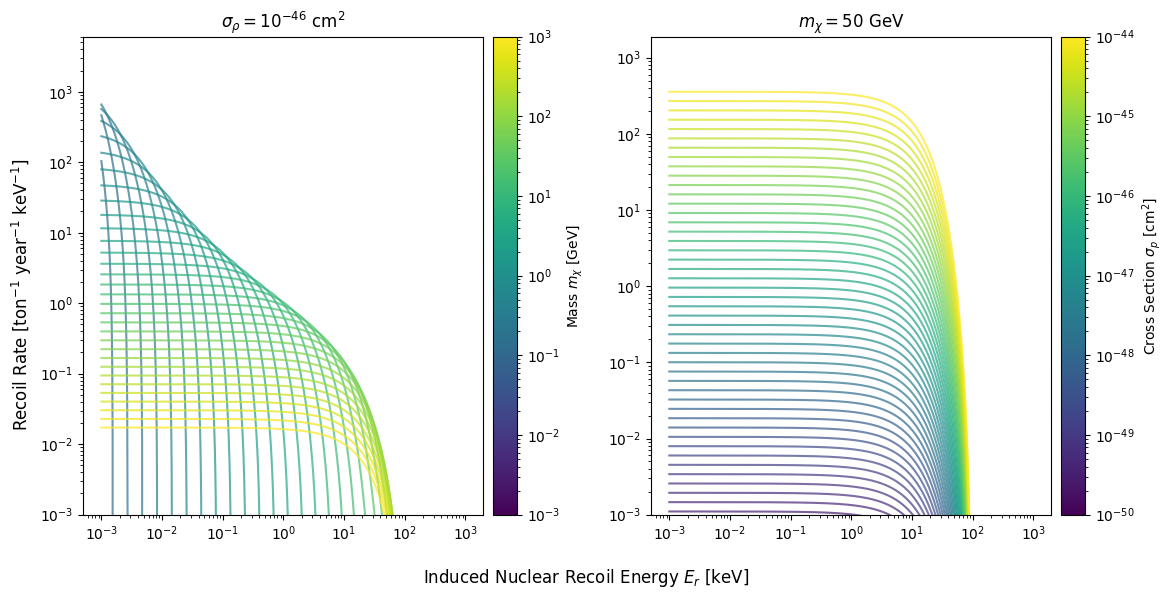

In [9]:
from dirdet.config.targets import XENON
from dirdet.wimp_rates import dRdE_WIMP

A = XENON.A     # target
E_r = np.geomspace(1e-3,1e3,1000)   # recoil energy

# parameters
m_arr = np.logspace(-3,3,50)        # mass array [GeV]
sig_arr = np.logspace(-50,-44,50)   # cross_sec array [sig_arr]
m_fix = 50                          # fixed mass 
sig_fix = 1e-47                     # fixed cross sec


# figure
fig, (ax_left, ax_right) = plt.subplots(1,2,figsize=(12,6))
fig.supxlabel("Induced Nuclear Recoil Energy $E_r$ [keV]")
fig.supylabel("Recoil Rate [ton$^{-1}$ year$^{-1}$ keV$^{-1}$]")

# colour bar normalisation
norm_m, cmap_m = colors.LogNorm(vmin=m_arr.min(), vmax=m_arr.max()), plt.get_cmap('viridis')
norm_s, cmap_s = colors.LogNorm(vmin=sig_arr.min(), vmax=sig_arr.max()), plt.get_cmap('viridis')

#--- LEFT PLOT, SIGMA FIXED ---#
for m in m_arr:
    dR = dRdE_WIMP(E_r,m_chi=m,sigma_p=sig_fix,A=A)
    color = cmap_m(norm_m(m))
    ax_left.loglog(E_r, dR, color=color, alpha=0.7)

ax_left.set_ylim(1e-3)
ax_left.set_title(f"$\\sigma_{{\\rho}}= 10^{{-46}}$ cm$^{{2}}$")

# create colour bar
sm_m = plt.cm.ScalarMappable(cmap=cmap_m, norm=norm_m)
cbar1 = fig.colorbar(sm_m, ax=ax_left, pad=0.02)
cbar1.set_label(r'Mass $m_{\chi}$ [GeV]')


#--- RIGHT PLOT, MASS FIXED ---#
for s in sig_arr:
    dR = dRdE_WIMP(E_r,m_chi=m_fix,sigma_p=s,A=A)
    color = cmap_s(norm_s(s))
    ax_right.loglog(E_r, dR, color=color, alpha=0.7)

ax_right.set_ylim(1e-3)   
ax_right.set_title(f"$m_{{\\chi}}= {m_fix}$ GeV")

# create colour bar
sm_s = plt.cm.ScalarMappable(cmap=cmap_s, norm=norm_s)
cbar2 = fig.colorbar(sm_s, ax=ax_right, pad=0.02)
cbar2.set_label(r'Cross Section $\sigma_p$ [cm$^2$]')


plt.tight_layout()
plt.show()

# Neutrino Overlay

We will now overlay the neutrino recoil rates onto the WIMP recoil rates to illustrate the satuaration of signals caused by the neutirno background. To do so we use different WIMP mass $m_{\chi}$ and cross section parameters $\sigma_{\rho}$. To calcualte the cross sections that closest match the neutrino recoil rate, Scipy's Basin hopping algortithm was used to minimise the difference. Crucially thought the bounds set are physically possible.

## Plot 

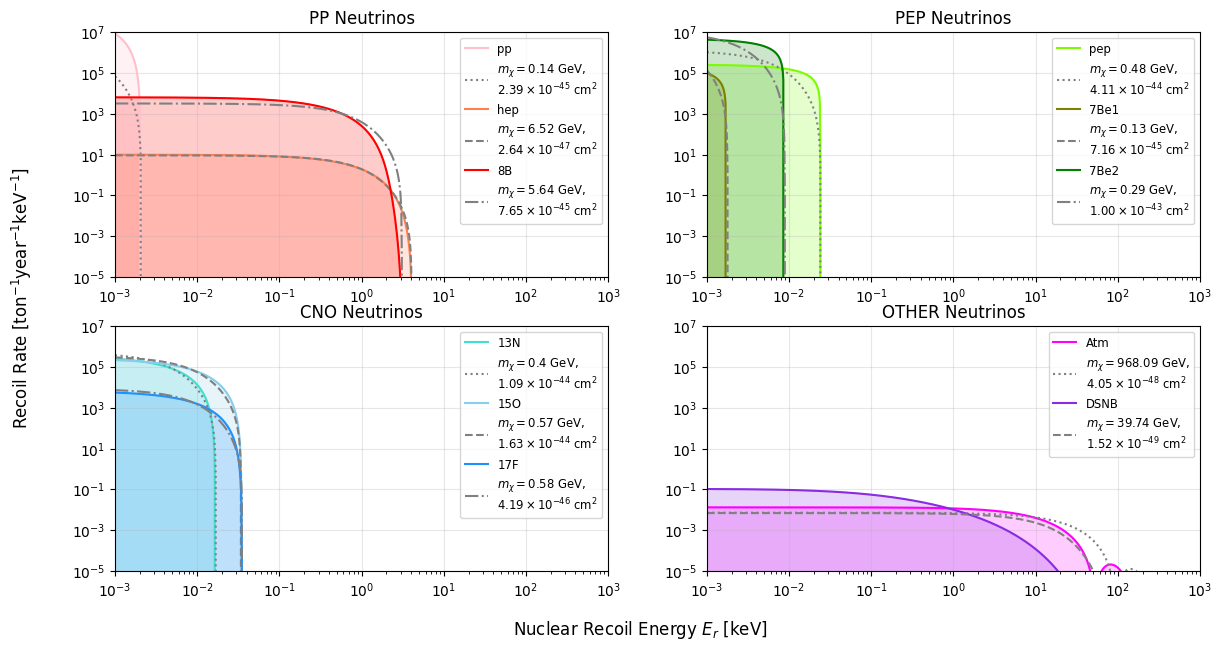

In [4]:
from dirdet.config.physics import NeutrinoRegistry, NeutrinoGroup, NUCLEAR, WIMP_PLOT_LINES
from dirdet.config.targets import XENON

from dirdet.neutrino_rates import dRdE_CEvNS
from dirdet.wimp_rates import dRdE_WIMP
from dirdet.plotting import plot_wimp_recoil, plot_neutrino_flavour

# energy range
E_r = np.geomspace(1e-3,1e3,1000)

#Initialize Plot (Presentation Layer)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()

fig.supxlabel("Nuclear Recoil Energy $E_{r}$ [keV]")
fig.supylabel("Recoil Rate [ton$^{-1}$year$^{-1}$keV$^{-1}$]", x=0.05)

xlim, ylim = (1e-3, 1e3), (1e-5, 1e7)

all_sources = NeutrinoRegistry.all_sources()

for i, group in enumerate(NeutrinoGroup):
    ax = axes[i]
    ax.set_title(f"{group.name} Neutrinos")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    group_sources = [s for s in all_sources if s.group == group]    # get sources in current loop

    for j,source in enumerate(group_sources):
        # calculate values
        E_nu, Flux = np.loadtxt(f"input_data/neutrino_fluxes/{source.name}.txt",unpack=True)
        dR_nu = dRdE_CEvNS(E_r=E_r,E_nu=E_nu,Flux=Flux,A=XENON.A,Z=XENON.Z)
        m_chi, sig_p = source.equiv_wimp_mass, source.equiv_wimp_sigma
        dR_wimp = dRdE_WIMP(E_r=E_r,m_chi=m_chi,sigma_p=sig_p,A=XENON.A)
        # plot
        plot_neutrino_flavour(ax=ax,source=source,x_arr=E_r,y_arr=dR_nu)
        plot_wimp_recoil(ax=ax,source=source,x_data=E_r,y_data=dR_wimp,ls_index=j)

    ax.legend(loc='best', fontsize='small', ncol=1)
    ax.grid(alpha=0.3)

plt.show()


# Expected Events

For the final section, we will plot the expected events as a fucntion of the WIMP-nucleon cross section **and** WIMP mass, that a hypothetical experiment may detect. Previously we have plotted the recoil rate vs the energy, and used different parameters. Now we will see how the expected event as a function of these parameters.

We define $E_{thresh}=1 \text{ keV}$ and $E_{max}=100 \text{ keV}$ as the minimum and maximum recoil energy our experinet can detect/handle. We define $\text{exposure}=1 \text{ ton year}$ as the exposure of the experiment, here it being interpreted as either a 1 ton experiment for 1 year.

To then calculate the expected events, we integrate our recoil rate over the energy range, and multiply it by the exposure, like so:
$$
\text{Events} = \text{exposure} \times \int_{E_{thresh}}^{E_{max}}\frac{dR}{dE_r} dE_r
$$

In [5]:
from dirdet.wimp_rates import dRdE_WIMP
from dirdet.config.targets import XENON

A = XENON.A

masses = np.logspace(0,3,100)
sigmas = np.logspace(-50,-43,100)

E_thresh = 1    # keV
E_max = 100     # keV
E_r_exp = np.linspace(E_thresh,E_max,1000)

exposure = 1 # 1 ton year

N_total = np.zeros((len(sigmas), len(masses)))

# calculate events 
for s,sigma_p in enumerate(sigmas):
    for m,m_chi in enumerate(masses):
        # calculate rate
        dR = dRdE_WIMP(E_r_exp,m_chi,sigma_p,A)
        # integrate
        N = np.trapezoid(dR,E_r_exp)*exposure
        N_total[s,m] = N

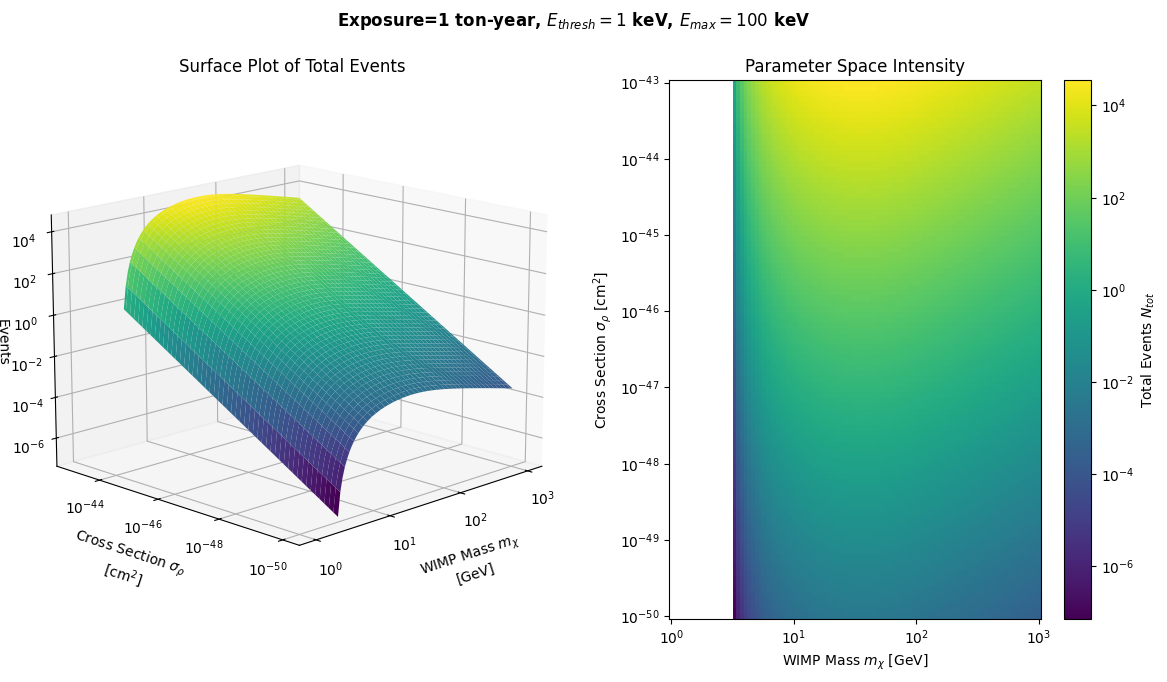

In [7]:
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

ax_left = fig.add_subplot(gs[0], projection='3d')
ax_right = fig.add_subplot(gs[1])

fig.suptitle(f"Exposure={exposure} ton-year, $E_{{thresh}}={E_thresh}$ keV, $E_{{max}}={E_max}$ keV",x=0.6,fontweight="bold")

M, S = np.meshgrid(masses, sigmas)

def log_tick_formatter(val, pos):
    return f"$10^{{{val:.0f}}}$"

# ------- SURFACE PLOT (Left) --------- #
N_safe = np.where(N_total > 0, N_total, np.nan)
surf = ax_left.plot_surface(np.log10(M), np.log10(S), np.log10(N_safe), cmap='viridis')

# Formatting
ax_left.set_box_aspect(None, zoom=1)  # change box aspect
# x-axis
ax_left.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax_left.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
ax_left.set_xlabel("WIMP Mass $m_{\\chi}$\n[GeV]",labelpad=15)
# y-axis
ax_left.yaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
ax_left.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
ax_left.set_ylabel("Cross Section $\\sigma_{\\rho}$\n[cm$^{2}$]",labelpad=15)
# z-axis
ax_left.zaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
ax_left.set_zlabel("Events")
ax_left.set_zlabel("Events", labelpad=0.5)
# title
ax_left.set_title(f"Surface Plot of Total Events")
ax_left.view_init(elev=15, azim=-135)

# ------- COLOR PLOT (Right) --------- #
mesh = ax_right.pcolormesh(np.log10(M), np.log10(S), np.log10(N_safe), 
                           cmap='viridis', shading='auto')
cbar = fig.colorbar(mesh, ax=ax_right)

# Formatting for ax_right
ax_right.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_right.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_right.xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
ax_right.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
ax_right.set_xlabel("WIMP Mass $m_{\\chi}$ [GeV]")
ax_right.set_ylabel("Cross Section $\\sigma_{\\rho}$ [cm$^{2}$]")
ax_right.set_title("Parameter Space Intensity")
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
cbar.ax.yaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
cbar.set_label("Total Events $N_{tot}$")

#plt.tight_layout()
plt.subplots_adjust(left=0.15, right=1, wspace=0.05)
plt.show()